# ANN Lab 9 — Self-Organising Map (SOM)

| Field | Detail |
|---|---|
| **Name** | Muhammad Taqui |
| **Enrollment No** | 01-136221-021 |
| **Class** | BS AI (6-A) |

## Theory

A **Self-Organising Map** is an unsupervised neural network that projects high-dimensional data onto a low-dimensional (typically 2D) grid while preserving topological structure.

**Algorithm:**
1. Initialise grid weights randomly.
2. For each input vector, find the **Best Matching Unit (BMU)** — the grid node with minimum Euclidean distance.
3. Update BMU and its neighbours:

$$w(t+1) = w(t) + \eta(t) \cdot h(d, \sigma(t)) \cdot (x - w(t))$$

where $h$ is a Gaussian neighbourhood function, $\sigma(t)$ decays over iterations, and $\eta(t)$ is the decaying learning rate.

**U-Matrix:** Average distance between each node and its neighbours — reveals cluster boundaries on the grid.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [8]:
# Replace with your actual dataset path
# data = pd.read_csv('/content/dc.csv')

# --- Synthetic placeholder (remove when using real data) ---
np.random.seed(42)
n_samples = 200
data = pd.DataFrame({
    'open_USD':  np.random.uniform(30000, 40000, n_samples),
    'high_USD':  np.random.uniform(31000, 42000, n_samples),
    'low_USD':   np.random.uniform(28000, 38000, n_samples),
    'close_USD': np.random.uniform(29000, 39000, n_samples),
})
# -----------------------------------------------------------

X = data.values.astype(float)
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

print(f"Dataset shape: {X_norm.shape}")
data.head()

Dataset shape: (200, 4)


,open_USD,high_USD,low_USD,close_USD
0,33745.401188,38062.348108,29031.238688,30689.350631
1,39507.143064,31925.539615,37025.529067,31785.903390
2,37319.939418,32777.915855,33052.523724,30770.104843
3,35986.584842,40884.096074,36264.574661,29887.025338
4,31560.186404,37670.719656,31200.496010,30206.358711


In [9]:
class SOM:
    """Minimal Self-Organising Map implementation."""

    def __init__(
        self,
        grid_x: int,
        grid_y: int,
        input_dim: int,
        learning_rate: float = 0.5,
        sigma: float | None = None,
        n_iterations: int = 50,
        seed: int = 42
    ):
        self.grid_x = grid_x
        self.grid_y = grid_y
        self.input_dim = input_dim
        self.lr0 = learning_rate
        self.sigma0 = sigma if sigma else max(grid_x, grid_y) / 2
        self.n_iter = n_iterations
        rng = np.random.default_rng(seed)
        self.weights = rng.random((grid_x, grid_y, input_dim))

    def _bmu(self, x: np.ndarray):
        dists = np.linalg.norm(self.weights - x, axis=2)
        return np.unravel_index(np.argmin(dists), dists.shape)

    def _decay(self, val0: float, t: int) -> float:
        return val0 * (1 - t / self.n_iter)

    def train(self, X: np.ndarray, verbose: bool = True):
        loss_history = []
        for t in range(self.n_iter):
            lr = self._decay(self.lr0, t)
            sig = self._decay(self.sigma0, t)
            if sig < 1e-6:
                sig = 1e-6

            epoch_dists = []
            for x in X:
                bmu = self._bmu(x)
                epoch_dists.append(np.linalg.norm(self.weights[bmu] - x))

                for i in range(self.grid_x):
                    for j in range(self.grid_y):
                        d2bmu = np.linalg.norm(np.array([i, j]) - np.array(bmu))
                        if d2bmu <= sig:
                            h = np.exp(-d2bmu**2 / (2 * sig**2))
                            self.weights[i, j] += lr * h * (x - self.weights[i, j])

            mean_dist = np.mean(epoch_dists)
            loss_history.append(mean_dist)
            if verbose and (t + 1) % 10 == 0:
                print(f"Iteration {t+1}/{self.n_iter}  Mean BMU distance: {mean_dist:.4f}")

        return loss_history

    def u_matrix(self) -> np.ndarray:
        u = np.zeros((self.grid_x, self.grid_y))
        for i in range(self.grid_x):
            for j in range(self.grid_y):
                neighbours = []
                for di in [-1, 0, 1]:
                    for dj in [-1, 0, 1]:
                        ni, nj = i + di, j + dj
                        if 0 <= ni < self.grid_x and 0 <= nj < self.grid_y:
                            neighbours.append(self.weights[ni, nj])
                u[i, j] = np.mean([np.linalg.norm(self.weights[i, j] - nb) for nb in neighbours])
        return u

In [4]:
som = SOM(
    grid_x=7,
    grid_y=7,
    input_dim=X_norm.shape[1],
    learning_rate=0.5,
    n_iterations=50,
    seed=42
)

loss_history = som.train(X_norm, verbose=True)

Iteration 10/50  Mean BMU distance: 0.3555
Iteration 20/50  Mean BMU distance: 0.3073
Iteration 30/50  Mean BMU distance: 0.2709
Iteration 40/50  Mean BMU distance: 0.1892
Iteration 50/50  Mean BMU distance: 0.1736


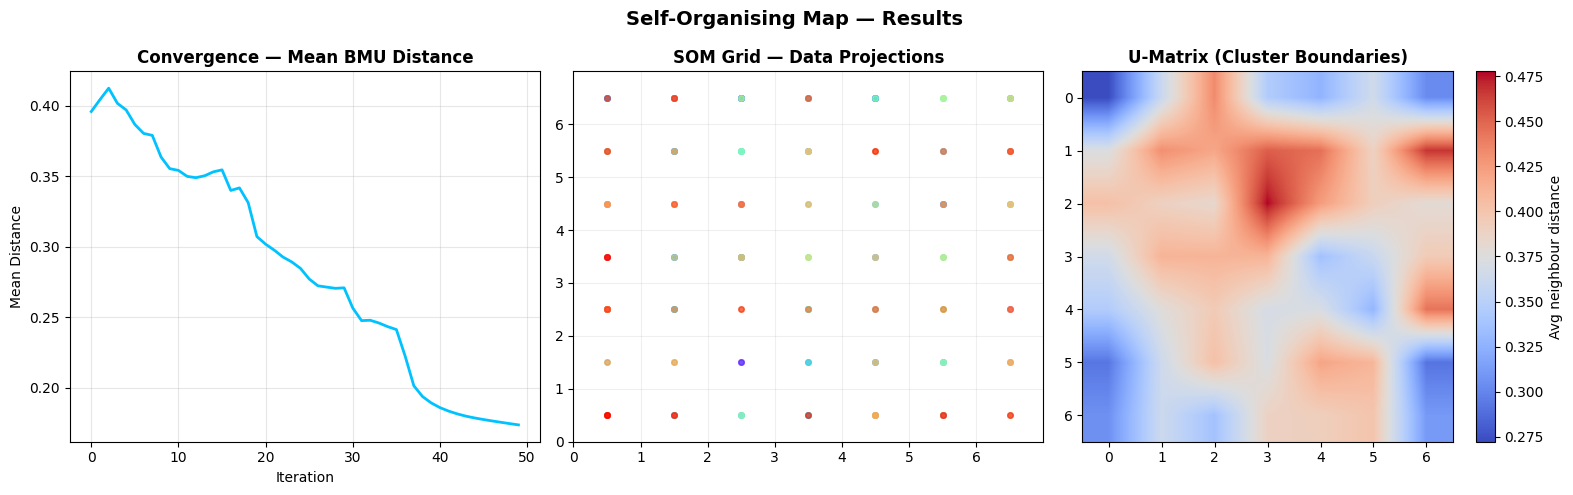

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Convergence curve ──────────────────────────────────────
axes[0].plot(loss_history, color='#00C2FF', linewidth=2)
axes[0].set_title('Convergence — Mean BMU Distance', fontweight='bold')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Mean Distance')
axes[0].grid(True, alpha=0.3)

# ── 2. SOM grid mapping ───────────────────────────────────────
axes[1].set_title('SOM Grid — Data Projections', fontweight='bold')
axes[1].set_xlim(0, som.grid_x)
axes[1].set_ylim(0, som.grid_y)
axes[1].set_xticks(range(som.grid_x))
axes[1].set_yticks(range(som.grid_y))
axes[1].grid(True, alpha=0.2)

cmap = plt.cm.rainbow
for idx, x in enumerate(X_norm):
    bmu = som._bmu(x)
    axes[1].plot(
        bmu[0] + 0.5, bmu[1] + 0.5, 'o',
        color=cmap(idx / len(X_norm)),
        markersize=4, alpha=0.6
    )

# ── 3. U-Matrix ───────────────────────────────────────────────
u = som.u_matrix()
im = axes[2].imshow(u, cmap='coolwarm', interpolation='bilinear')
axes[2].set_title('U-Matrix (Cluster Boundaries)', fontweight='bold')
plt.colorbar(im, ax=axes[2], label='Avg neighbour distance')

plt.suptitle('Self-Organising Map — Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

The SOM converges as shown by the declining BMU distance curve. The grid projection reveals how the high-dimensional data distributes across the 7×7 map. The U-Matrix identifies cluster boundaries — darker regions mark transition zones between clusters, lighter regions mark dense clusters.

In [6]:
# iTaqiZ - PK